# **CLASIFICADOR DE IMÁGENES**

En este ejercicio vamos a utilizar el Perceptrón para solucionar un problema más complejo que el anterior. En este caso, nuestro objetivo será clasificar un conjunto de imágenes en base al número que se muestra en las mismas.

# **1. Lectura del conjunto de datos**

In [14]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784')

# **2. Visualización del conjunto de datos**

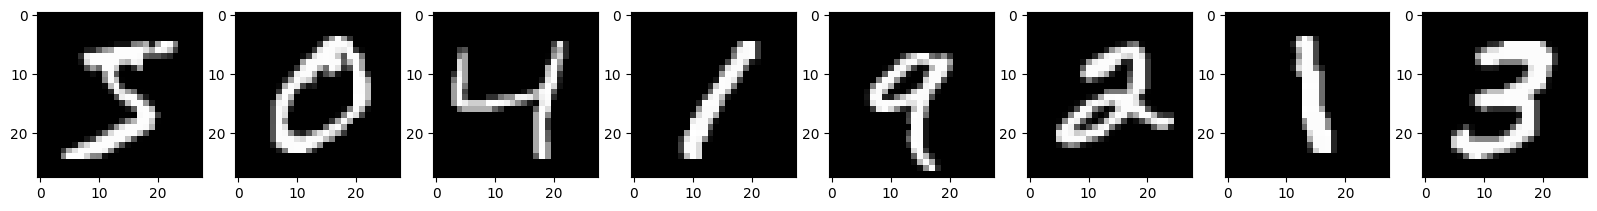

In [16]:
import numpy as np
import matplotlib.pyplot as plt

data = mnist.data.to_numpy()

plt.figure(figsize=(20,4))
for index, digit in zip(range(1,9), data[:8]):
  plt.subplot(1,8,index)
  plt.imshow(np.reshape(digit, (28,28)), cmap = plt.cm.gray )
plt.show()

In [18]:
df = mnist.data
df

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# **3. División del conjunto de datos**

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(mnist.data,mnist.target, test_size = 0.2)

# **4. Entrenamiento del algoritmo**


In [53]:
from sklearn.linear_model import Perceptron
clf = Perceptron()
clf.fit(X_train,y_train)

Perceptron()

In [54]:
# Número de parámetros del modelo
clf.coef_.shape

(10, 784)

In [55]:
# Parámetros bias/intercept
clf.intercept_.shape

(10,)

# **5. Predicción con el conjunto de pruebas**

In [56]:
y_pred = clf.predict(X_test)

In [57]:
from sklearn.metrics import f1_score
f1_score(y_test, y_pred, average='weighted')

0.8840183381724024

# **6. Mostrando las imágenes mal clasificadas**

In [58]:
import numpy as np
import matplotlib.pyplot as plt

data = mnist.data.to_numpy()

index = 0
index_errors = []
for label, predict in zip(y_test, y_pred):
  if label != predict:
    index_errors.append(index)
  index += 1

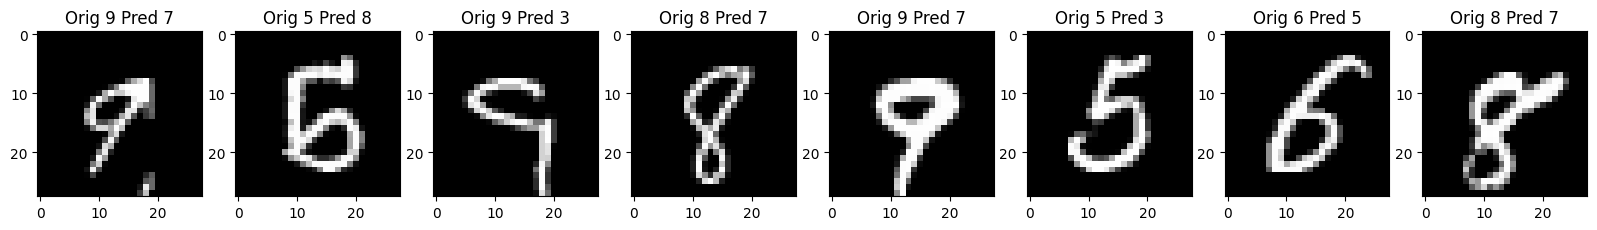

In [59]:
import numpy as np
import matplotlib.pyplot as plt

data = mnist.data.to_numpy()

plt.figure(figsize=(20,4))
for i, img_index in zip(range(1,9), index_errors[8:16]):
  plt.subplot(1,8,i)
  plt.imshow(np.reshape(X_test.to_numpy()[img_index], (28,28)), cmap = plt.cm.gray )
  plt.title("Orig "+ str(y_test.to_numpy()[img_index]) + " Pred " + str(y_pred[img_index]))
plt.show()

# **6. Exportamos el modelo**

In [60]:
import joblib

joblib.dump(clf, "clf_imagen.pkl")

['clf_imagen.pkl']

# **7. Prueba final**

In [65]:
import cv2
import numpy as np
import joblib
modelo = joblib.load("/content/clf_imagen.pkl")
img = cv2.imread("/content/n3.png",0)
img_rescaled = cv2.resize(img, (28,28))
img_vector = img_rescaled.flatten().reshape(1,-1)
predicion = modelo.predict(img_vector)
print("La clase predicha es:", predicion[0])

La clase predicha es: 3


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(
